# Experiment 8: Clustering Human Activity Recognition Data using K-Means, DBSCAN and Hierarchical Clustering

**Course:** ICS1512 – Machine Learning Algorithms Laboratory  
**Name:** Chitraju Vishnu Vineeth  |  **Register No.:** 3122247001012

## 1. Aim and Objective
To implement and analyse three clustering algorithms on the **Human Activity Recognition (HAR) Using Smartphones** dataset and compare them with the true activity labels:

| Model | Algorithm |
|---|---|
| A | K-Means (k chosen with the Elbow method + Silhouette score) |
| B | DBSCAN (ε and minPts tuned with a k-distance graph and a small grid) |
| C | Hierarchical Agglomerative Clustering (Ward's linkage, dendrogram, linkage comparison) |

**Dataset:** 30 volunteers, 6 activities (WALKING, WALKING_UPSTAIRS, WALKING_DOWNSTAIRS, SITTING, STANDING, LAYING), 561 time/frequency-domain features per 2.56 s window.  
The **train** and **test** parts of the UCI HAR dataset are combined (all 30 volunteers, 10299 windows). The three raw text files of each part (features, subject id, activity id) are merged into one table with the columns `subject` and `Activity`.

## Imports

In [1]:
import os, zipfile
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.feature_selection import f_classif            # used inside the EDA function
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import (silhouette_score, davies_bouldin_score, calinski_harabasz_score,
                             adjusted_rand_score, normalized_mutual_info_score)
from scipy.cluster.hierarchy import linkage, dendrogram

## 2. Preprocessing Steps
1. Load the dataset.
2. **Handle missing values** (fill numeric gaps with the column median – the HAR data normally has none).
3. **Encode the categorical label** `Activity` (text → numbers). The label is *only* used for evaluation, never for clustering.
4. Separate the 561 features (`X`) from `subject` and `Activity`.
5. **Standardization** (`StandardScaler`) is done in the PCA cell of Section 4.

In [3]:
DATA_DIR = "UCI HAR Dataset"            # <-- folder of the extracted dataset
if not os.path.exists(DATA_DIR):         # extract UCI_HAR_Dataset.zip (placed next to this notebook) if needed
    zipfile.ZipFile("UCI HAR Dataset.zip").extractall(".")

# feature names (a few names are repeated in features.txt -> add _1, _2 ... to make them unique)
feat = pd.read_csv(f"{DATA_DIR}/features.txt", sep=r"\s+", header=None)[1]
dup = feat.duplicated(keep=False)
feat[dup] = feat[dup] + "_" + (feat.groupby(feat).cumcount() + 1)[dup].astype(str)

# activity id -> activity name
names = pd.read_csv(f"{DATA_DIR}/activity_labels.txt", sep=r"\s+", header=None, index_col=0)[1]

# merge features + subject + activity for the train and test parts
parts = []
for split in ["train", "test"]:
    features = pd.read_csv(f"{DATA_DIR}/{split}/X_{split}.txt", sep=r"\s+", header=None, names=feat)
    subject = pd.read_csv(f"{DATA_DIR}/{split}/subject_{split}.txt", header=None, names=["subject"])
    activity = pd.read_csv(f"{DATA_DIR}/{split}/y_{split}.txt", header=None)[0].map(names).rename("Activity")
    parts.append(pd.concat([features, subject, activity], axis=1))
df = pd.concat(parts, ignore_index=True)
print("Dataset shape:", df.shape)

# 1. missing values
print("Total missing values:", df.isnull().sum().sum())
df = df.fillna(df.median(numeric_only=True))

# 2. encode the activity labels (used only for evaluation)
activity = df["Activity"]
le = LabelEncoder()
y_true = le.fit_transform(activity)
true_k = len(le.classes_)
print("Label encoding:", dict(zip(le.classes_, range(true_k))))

# 3. features only (drop the label and the volunteer id)
X = df.drop(columns=["Activity", "subject"], errors="ignore")
print("Feature matrix shape:", X.shape)

Dataset shape: (10299, 563)
Total missing values: 0
Label encoding: {'LAYING': 0, 'SITTING': 1, 'STANDING': 2, 'WALKING': 3, 'WALKING_DOWNSTAIRS': 4, 'WALKING_UPSTAIRS': 5}
Feature matrix shape: (10299, 561)


## 3. Exploratory Data Analysis (EDA)
Standard EDA function (same in every experiment): shape, types, missing values, distributions, outliers, correlation, pair plot and class distribution.

EXPLORATORY DATA ANALYSIS

Target Column : Activity

Dataset Shape
(10299, 563)

Column Names
['tBodyAcc-mean()-X', 'tBodyAcc-mean()-Y', 'tBodyAcc-mean()-Z', 'tBodyAcc-std()-X', 'tBodyAcc-std()-Y', 'tBodyAcc-std()-Z', 'tBodyAcc-mad()-X', 'tBodyAcc-mad()-Y', 'tBodyAcc-mad()-Z', 'tBodyAcc-max()-X', 'tBodyAcc-max()-Y', 'tBodyAcc-max()-Z', 'tBodyAcc-min()-X', 'tBodyAcc-min()-Y', 'tBodyAcc-min()-Z', 'tBodyAcc-sma()', 'tBodyAcc-energy()-X', 'tBodyAcc-energy()-Y', 'tBodyAcc-energy()-Z', 'tBodyAcc-iqr()-X', 'tBodyAcc-iqr()-Y', 'tBodyAcc-iqr()-Z', 'tBodyAcc-entropy()-X', 'tBodyAcc-entropy()-Y', 'tBodyAcc-entropy()-Z', 'tBodyAcc-arCoeff()-X,1', 'tBodyAcc-arCoeff()-X,2', 'tBodyAcc-arCoeff()-X,3', 'tBodyAcc-arCoeff()-X,4', 'tBodyAcc-arCoeff()-Y,1', 'tBodyAcc-arCoeff()-Y,2', 'tBodyAcc-arCoeff()-Y,3', 'tBodyAcc-arCoeff()-Y,4', 'tBodyAcc-arCoeff()-Z,1', 'tBodyAcc-arCoeff()-Z,2', 'tBodyAcc-arCoeff()-Z,3', 'tBodyAcc-arCoeff()-Z,4', 'tBodyAcc-correlation()-X,Y', 'tBodyAcc-correlation()-X,Z', 'tBodyAcc-c

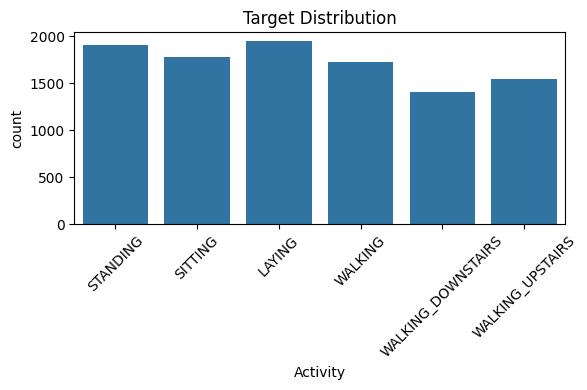


Distribution Analysis


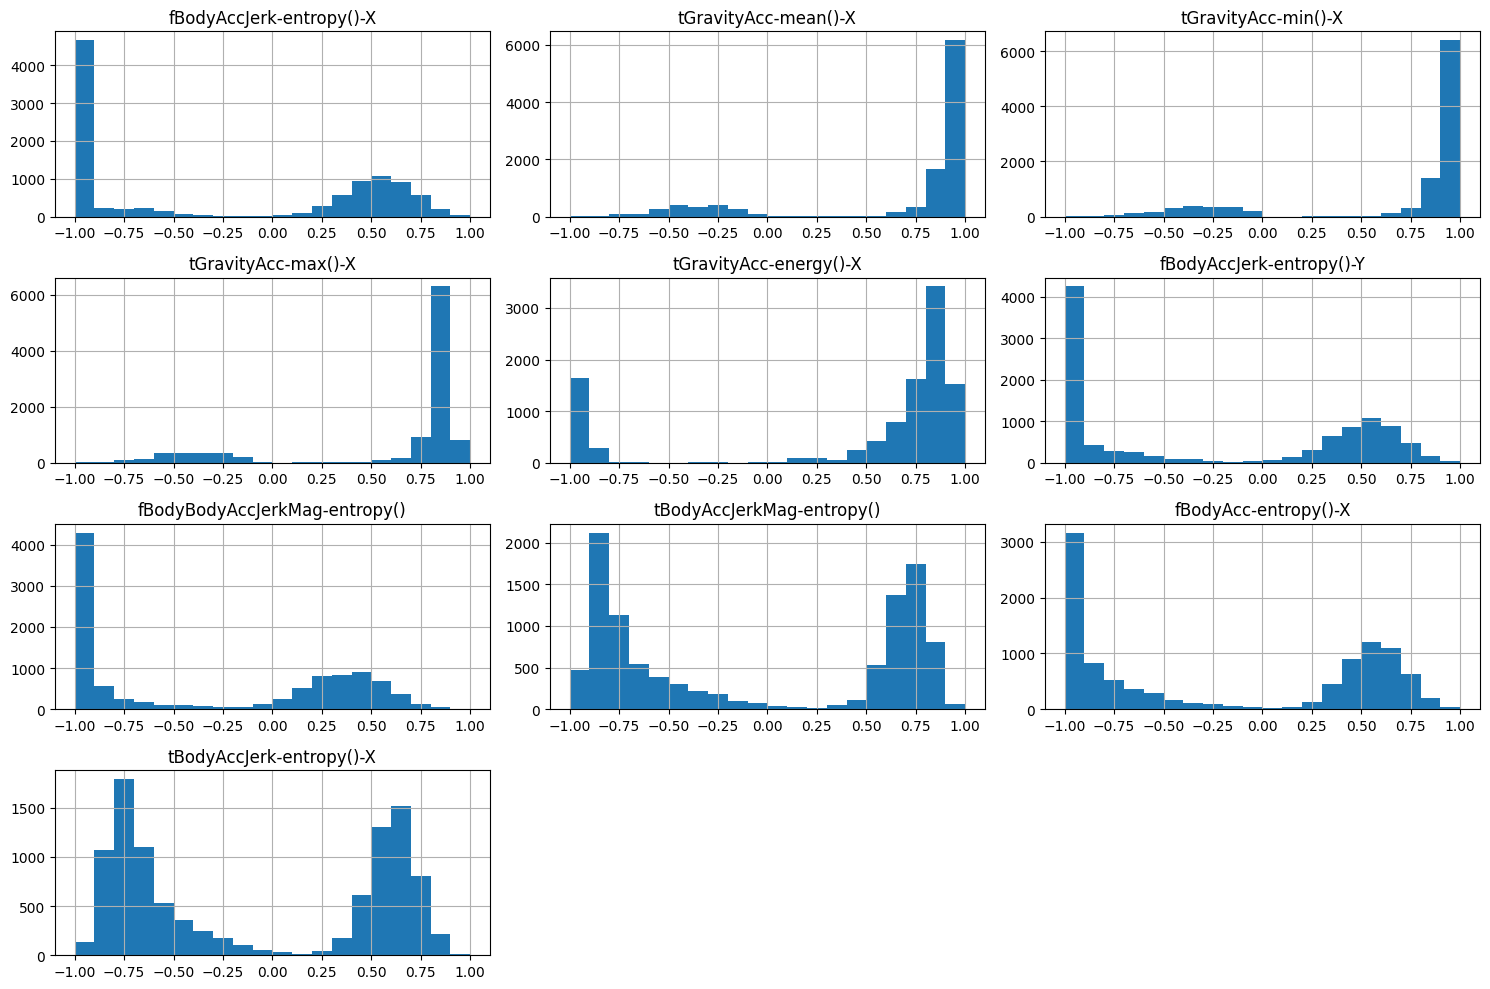


Outlier Detection


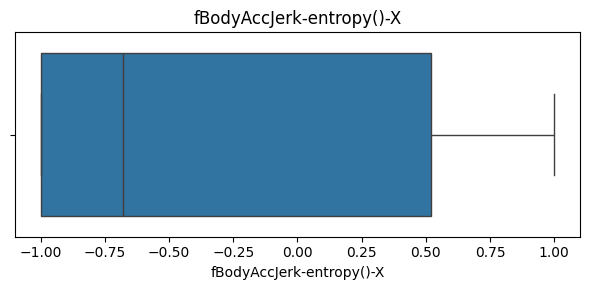

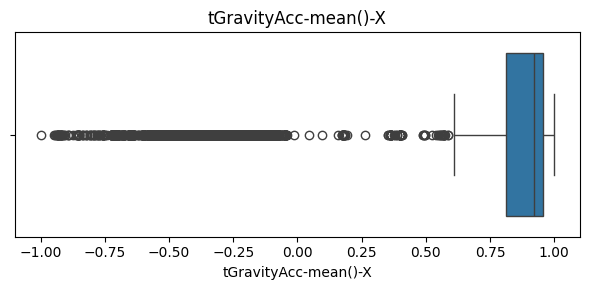

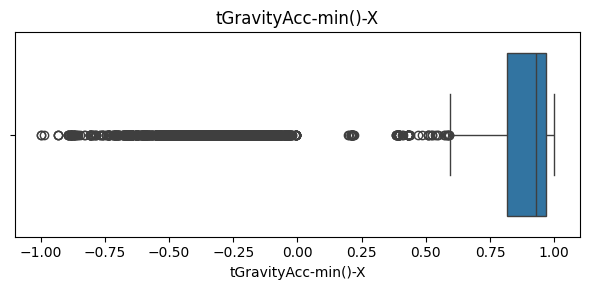

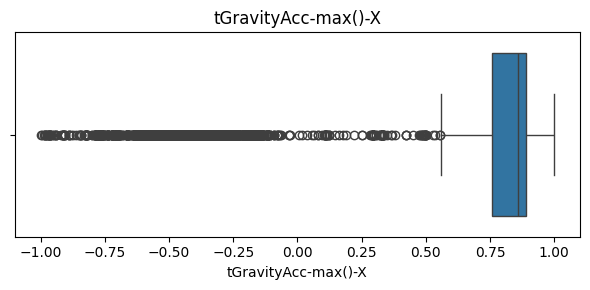

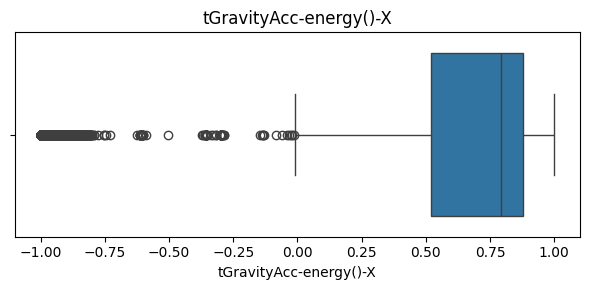

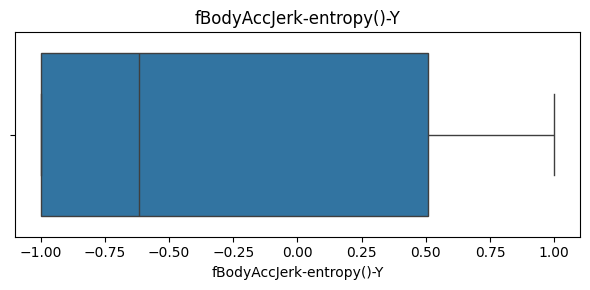

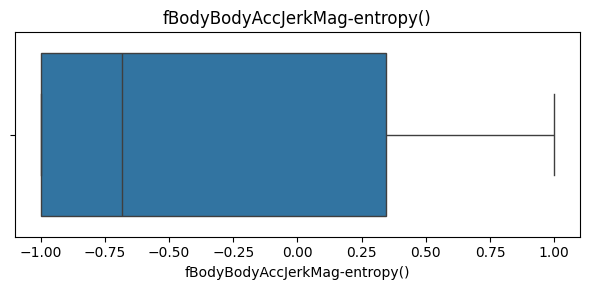

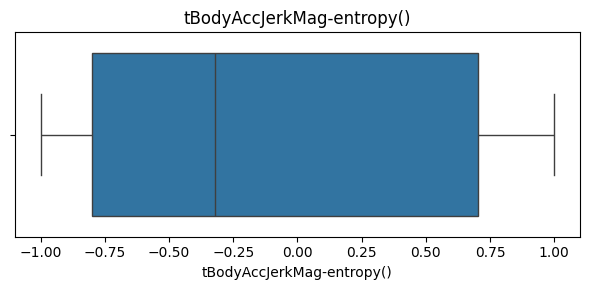

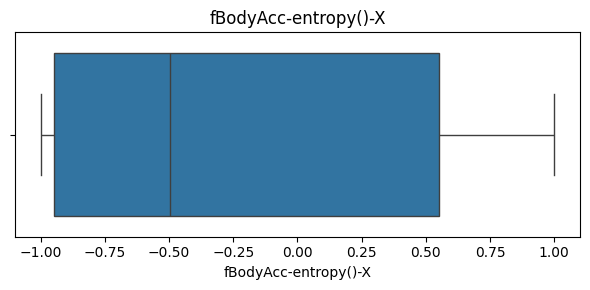

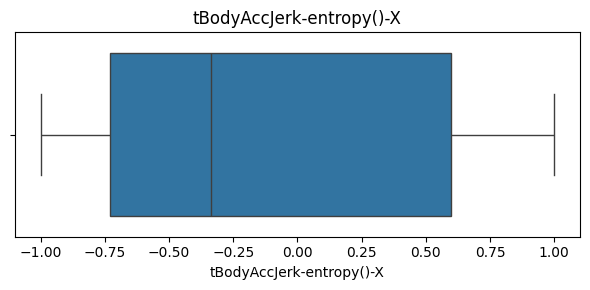


Correlation Heatmap


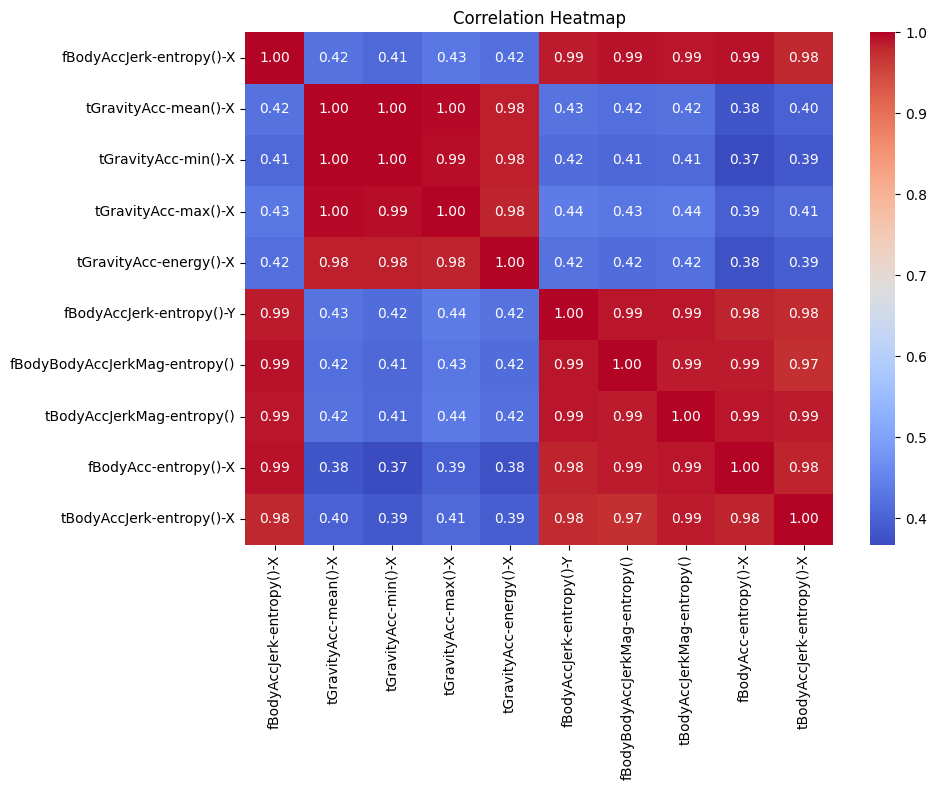


Pair Plot


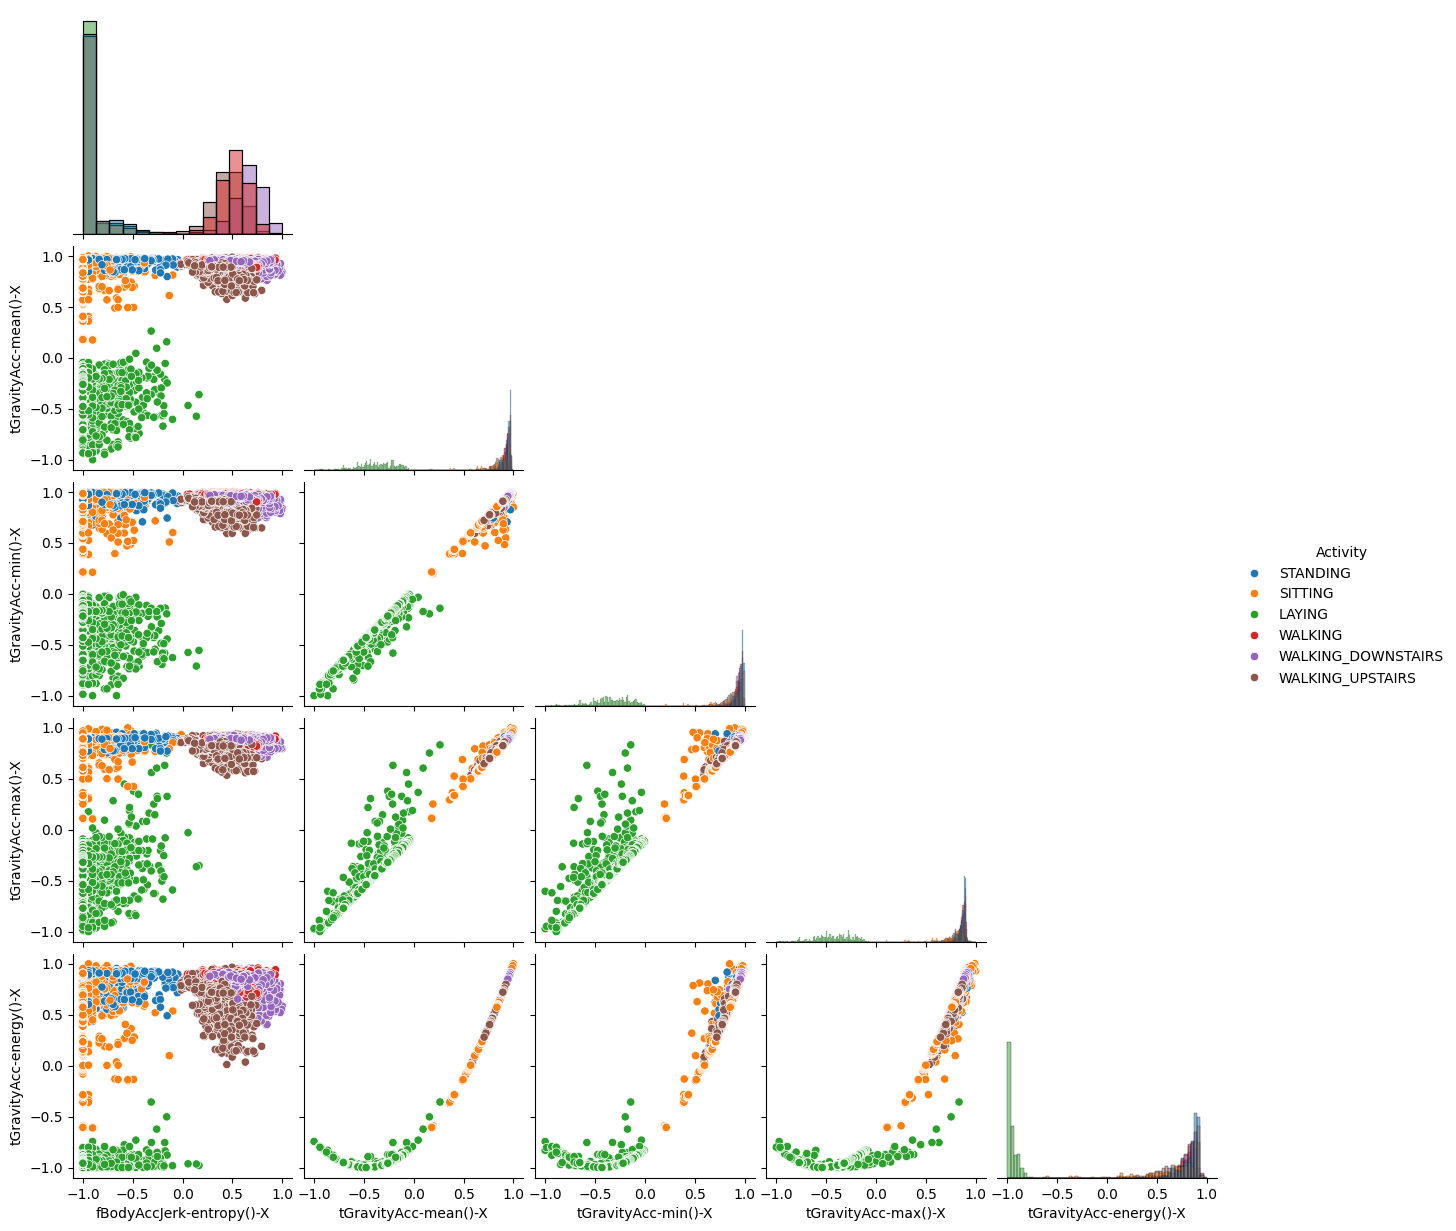


Relationship with Target


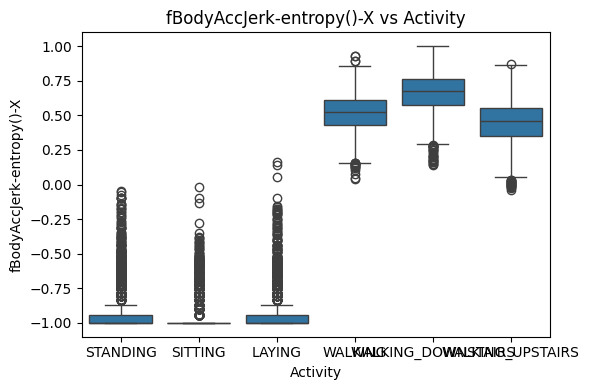

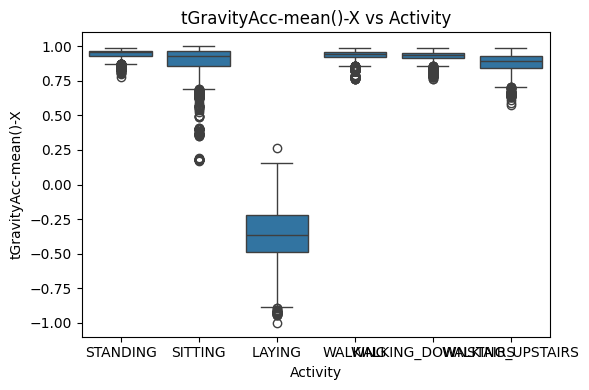

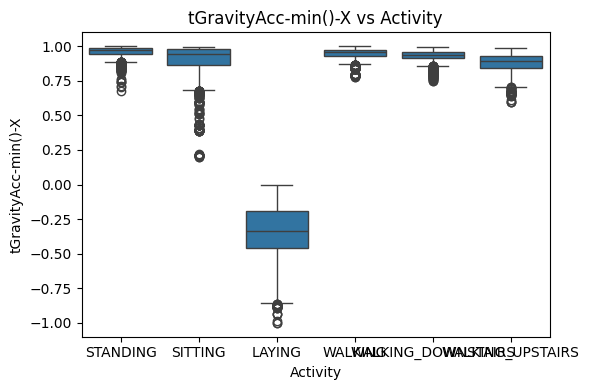

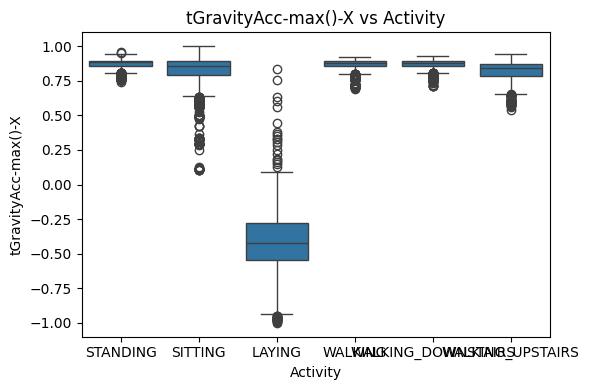

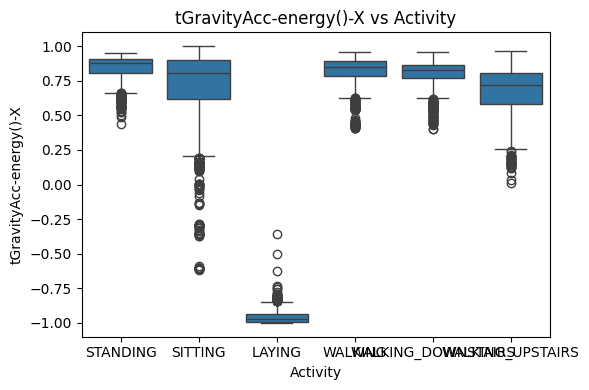

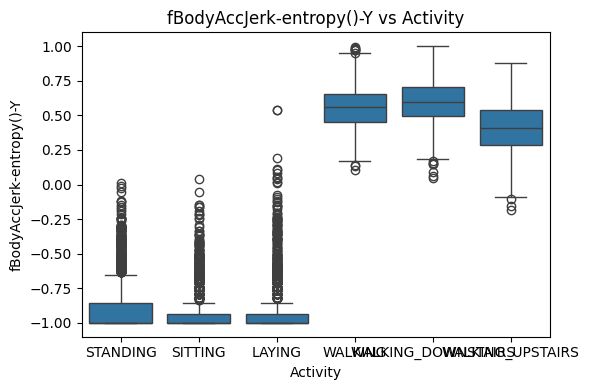

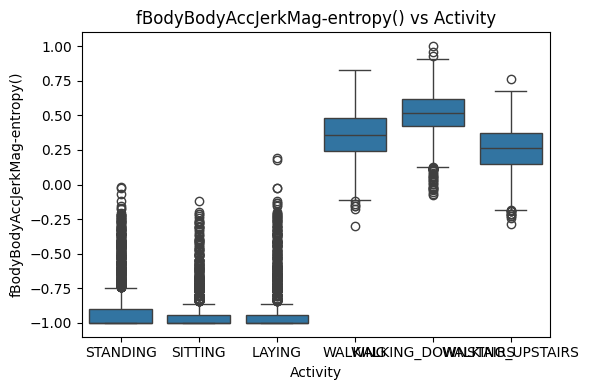

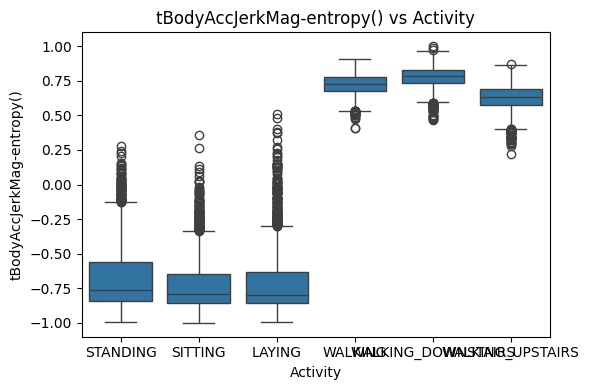

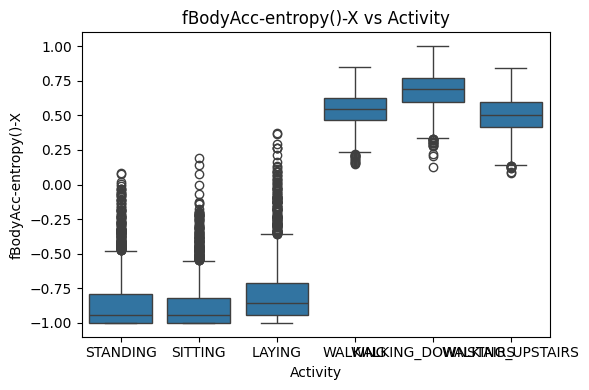

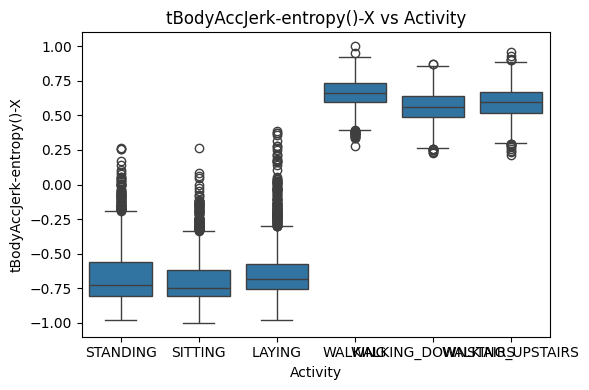


Categorical Analysis


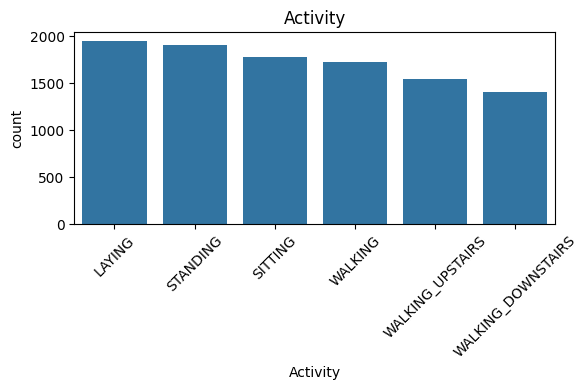


Skewness
tBodyAcc-mean()-X                      -3.490402
tBodyAcc-mean()-Y                      -0.429086
tBodyAcc-mean()-Z                       1.759648
tBodyAcc-std()-X                        0.637015
tBodyAcc-std()-Y                        0.435296
                                          ...   
angle(tBodyGyroJerkMean,gravityMean)    0.017421
angle(X,gravityMean)                    1.423169
angle(Y,gravityMean)                   -1.425668
angle(Z,gravityMean)                   -0.907224
subject                                -0.123430
Length: 562, dtype: float64

Kurtosis
tBodyAcc-mean()-X                        50.620456
tBodyAcc-mean()-Y                       181.632251
tBodyAcc-mean()-Z                        84.171056
tBodyAcc-std()-X                         -0.924923
tBodyAcc-std()-Y                         -1.326461
                                           ...    
angle(tBodyGyroJerkMean,gravityMean)     -0.915381
angle(X,gravityMean)                      0.407229
angle


Categorical Analysis


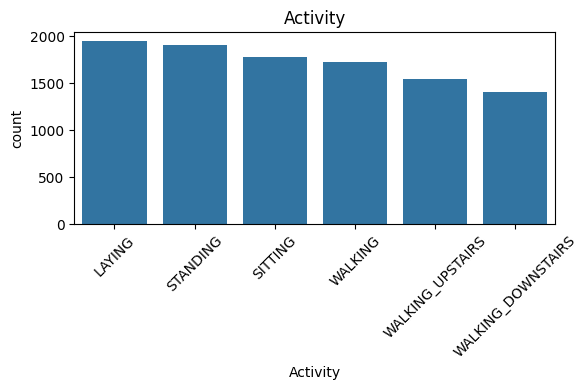


Skewness
tBodyAcc-mean()-X                      -3.490402
tBodyAcc-mean()-Y                      -0.429086
tBodyAcc-mean()-Z                       1.759648
tBodyAcc-std()-X                        0.637015
tBodyAcc-std()-Y                        0.435296
                                          ...   
angle(tBodyGyroJerkMean,gravityMean)    0.017421
angle(X,gravityMean)                    1.423169
angle(Y,gravityMean)                   -1.425668
angle(Z,gravityMean)                   -0.907224
subject                                -0.123430
Length: 562, dtype: float64

Kurtosis


tBodyAcc-mean()-X                        50.620456
tBodyAcc-mean()-Y                       181.632251
tBodyAcc-mean()-Z                        84.171056
tBodyAcc-std()-X                         -0.924923
tBodyAcc-std()-Y                         -1.326461
                                           ...    
angle(tBodyGyroJerkMean,gravityMean)     -0.915381
angle(X,gravityMean)                      0.407229
angle(Y,gravityMean)                      1.502170
angle(Z,gravityMean)                      1.827280
subject                                  -1.187193
Length: 562, dtype: float64

EDA COMPLETED SUCCESSFULLY


In [4]:
def _get_important_features(df, target, numeric, max_features):
    """Automatically select important numerical features."""
    numeric = list(numeric)

    if target in numeric:
        try:
            corr = (
                df[numeric]
                .corr()[target]
                .abs()
                .sort_values(ascending=False)
            )
            feats = corr.index.drop(target).tolist()
            return feats[:max_features]
        except Exception:
            pass

    try:
        X = df[numeric].drop(columns=[target], errors="ignore")
        y = df[target]

        if X.shape[1] > 0:
            scores, _ = f_classif(X.fillna(X.median()), y)
            ranking = (
                pd.Series(scores, index=X.columns)
                .sort_values(ascending=False)
            )
            return ranking.head(max_features).index.tolist()

    except Exception:
        pass

    return [c for c in numeric if c != target][:max_features]


def perform_eda(
    df,
    target=None,
    max_features=10,
    pairplot_features=5,
    max_categories=20
):
    """
    Universal EDA Function.

    Parameters
    ----------
    df : pandas.DataFrame
    target : str or None
        Target column name. If None, last column is assumed.
    max_features : int
        Maximum numerical features for plots.
    pairplot_features : int
        Maximum features used in pairplot.
    max_categories : int
        Maximum unique categories for countplots.
    """

    print("=" * 70)
    print("EXPLORATORY DATA ANALYSIS")
    print("=" * 70)

    if target is None:
        target = df.columns[-1]

    print(f"\nTarget Column : {target}")

    print("\nDataset Shape")
    print(df.shape)

    print("\nColumn Names")
    print(df.columns.tolist())

    print("\nData Types")
    print(df.dtypes)

    print("\nDataset Info")
    df.info()

    print("\nFirst 5 Rows")
    print(df.head())

    print("\nLast 5 Rows")
    print(df.tail())

    print("\nMissing Values")
    print(df.isnull().sum())

    print("\nMissing Value Percentage")
    print((df.isnull().sum() / len(df)) * 100)

    print("\nDuplicate Rows :", df.duplicated().sum())

    print("\nUnique Values")
    print(df.nunique())

    print("\nStatistical Summary")
    print(df.describe(include="all"))

    numeric = df.select_dtypes(include=np.number).columns.tolist()
    categorical = df.select_dtypes(
        include=["object", "category", "bool"]
    ).columns.tolist()

    print("\nNumerical Columns")
    print(numeric)

    print("\nCategorical Columns")
    print(categorical)

    important = _get_important_features(
        df,
        target,
        numeric,
        max_features
    )

    print("\nImportant Features Selected")
    print(important)

    # ---------------------------
    # Class Distribution
    # ---------------------------
    if target in categorical:
        plt.figure(figsize=(6,4))
        sns.countplot(x=df[target])
        plt.title("Target Distribution")
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.show()

    # ---------------------------
    # Histograms
    # ---------------------------
    if important:
        print("\nDistribution Analysis")
        df[important].hist(
            figsize=(15,10),
            bins=20
        )
        plt.tight_layout()
        plt.show()

    # ---------------------------
    # Boxplots
    # ---------------------------
    if important:
        print("\nOutlier Detection")

        for col in important:
            plt.figure(figsize=(6,3))
            sns.boxplot(x=df[col])
            plt.title(col)
            plt.tight_layout()
            plt.show()

    # ---------------------------
    # Heatmap
    # ---------------------------
    if len(important) > 1:
        print("\nCorrelation Heatmap")

        plt.figure(figsize=(10,8))

        sns.heatmap(
            df[important].corr(),
            annot=True,
            cmap="coolwarm",
            fmt=".2f"
        )

        plt.title("Correlation Heatmap")
        plt.tight_layout()
        plt.show()

    # ---------------------------
    # Pairplot
    # ---------------------------
    if len(important) >= 2:

        pair_cols = important[:pairplot_features]

        if target not in pair_cols:
            pair_cols.append(target)

        print("\nPair Plot")

        if target in categorical:

            sns.pairplot(
                df[pair_cols],
                hue=target,
                diag_kind="hist",
                corner=True
            )

        else:

            sns.pairplot(
                df[pair_cols],
                diag_kind="hist",
                corner=True
            )

        plt.show()

    # ---------------------------
    # Target Relationship
    # ---------------------------
    if target in categorical:

        print("\nRelationship with Target")

        for col in important:

            plt.figure(figsize=(6,4))

            sns.boxplot(
                x=df[target],
                y=df[col]
            )

            plt.title(f"{col} vs {target}")

            plt.tight_layout()

            plt.show()

    # ---------------------------
    # Countplots
    # ---------------------------
    if categorical:

        print("\nCategorical Analysis")

        for col in categorical:

            if df[col].nunique() <= max_categories:

                plt.figure(figsize=(6,4))

                sns.countplot(
                    x=df[col],
                    order=df[col].value_counts().index
                )

                plt.xticks(rotation=45)

                plt.title(col)

                plt.tight_layout()

                plt.show()

            else:
                print(f"Skipping '{col}' (>{max_categories} unique categories).")

    # ---------------------------
    # Skewness
    # ---------------------------
    if numeric:
        print("\nSkewness")
        print(df[numeric].skew())

        print("\nKurtosis")
        print(df[numeric].kurt())

    print("\n" + "=" * 70)
    print("EDA COMPLETED SUCCESSFULLY")
    print("=" * 70)

perform_eda(df)

## 4. Standardization and PCA (Dimensionality Reduction)
* `StandardScaler` gives every feature mean 0 and standard deviation 1 (clustering uses distances, so scale matters).
* PCA is used to (a) find how many components keep 95 % of the variance and (b) get 2-D coordinates for plotting.

The PCA code is the standard one used in the other experiments – only the train/test split is removed (clustering is unsupervised, so the whole data is used).

Explained Variance Ratio per PC: [5.07382210e-01 6.23918578e-02 2.69256386e-02 2.45287097e-02
 1.88893566e-02 1.63139540e-02 1.41453324e-02 1.21621062e-02
 9.85247564e-03 9.49228193e-03 8.58303631e-03 8.09979908e-03
 7.65862670e-03 6.76667617e-03 6.30241618e-03 6.15717733e-03
 5.95334955e-03 5.77195494e-03 5.63431287e-03 5.40829854e-03
 5.18827870e-03 5.02741666e-03 4.73229478e-03 4.63818462e-03
 4.46848418e-03 4.39868265e-03 4.16863053e-03 4.00808602e-03
 3.89071892e-03 3.81338573e-03 3.66869737e-03 3.64357439e-03
 3.49224522e-03 3.46736068e-03 3.35538910e-03 3.29410516e-03
 3.23824350e-03 3.00508156e-03 2.94253973e-03 2.90452465e-03
 2.75764996e-03 2.69864104e-03 2.64195735e-03 2.58030269e-03
 2.55030824e-03 2.47775822e-03 2.45537494e-03 2.38290353e-03
 2.35901952e-03 2.32043684e-03 2.28360307e-03 2.19181663e-03
 2.12631367e-03 2.09144562e-03 2.03479658e-03 2.01166715e-03
 1.98110752e-03 1.94391328e-03 1.92509135e-03 1.89538994e-03
 1.86403243e-03 1.82922763e-03 1.80956476e-03 1.7636

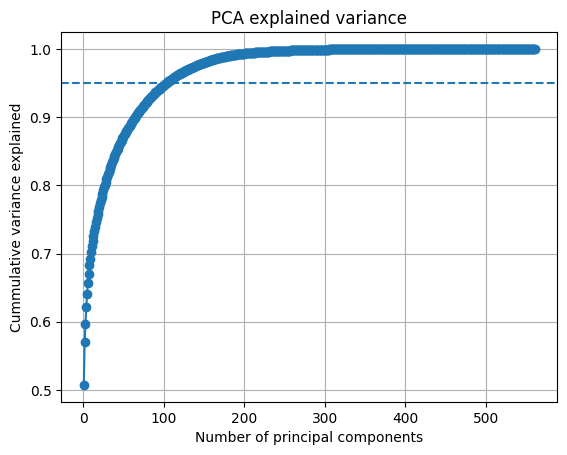

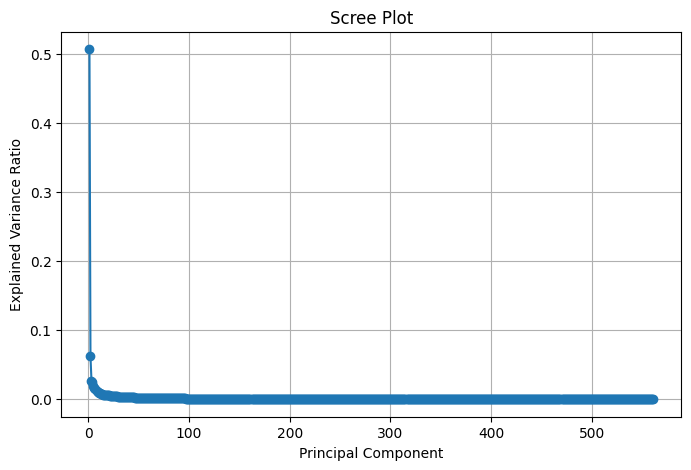


Components required for 95% variance is :104


In [5]:
scalar=StandardScaler()

X_scaled=scalar.fit_transform(X)

pca=PCA()

X_pca=pca.fit_transform(X_scaled)


print("Explained Variance Ratio per PC:", pca.explained_variance_ratio_)

cummulative_variance=np.cumsum(pca.explained_variance_ratio_)

print(f"\nCummulative variance: {cummulative_variance}\n")

#scree plot for analysing how much var is retained as we keep more and more principal components

plt.plot(range(1,len(cummulative_variance)+1),cummulative_variance,marker='o')
plt.axhline(y=0.95,linestyle="--")
plt.xlabel("Number of principal components")
plt.ylabel("Cummulative variance explained")
plt.title("PCA explained variance")
plt.grid()

plt.show()


# Scree Plot

plt.figure(figsize=(8, 5))

plt.plot(
    range(1, len(pca.explained_variance_ratio_) + 1),
    pca.explained_variance_ratio_,
    marker='o'
)

plt.xlabel("Principal Component")
plt.ylabel("Explained Variance Ratio")
plt.title("Scree Plot")
plt.grid()

plt.show()


#to find the no of components that are required to attain a var of 0.95

n_components=np.argmax(cummulative_variance>=0.95)+1

print(f"\nComponents required for 95% variance is :{n_components}")

In [6]:
# PCA Summary Table

pca_summary = pd.DataFrame({
    "Setting": ["With-PCA"],
    "Chosen Components": [n_components],
    "Variance Target": ["95%"],
    "Explained Variance (%)": [
        cummulative_variance[n_components - 1] * 100
    ],
    "Justification": [
        f"Reduce {X.shape[1]} original features (several highly correlated / redundant) to {n_components} components while retaining approximately 95% variance"
    ]
})

pca_summary

,Setting,Chosen Components,Variance Target,Explained Variance (%),Justification
0,With-PCA,104,95%,95.047032,Reduce 561 original features (several highly c...


**Data used for clustering**

* `X_cluster` – the first `n_components` principal components (95 % variance). All three algorithms cluster this data: it removes redundant / noisy features, makes distances more meaningful (important for DBSCAN) and is faster.
* `X_2d` – the first two principal components, used only for the 2-D scatter plots.

*(To cluster on all 561 standardized features instead, use `X_cluster = X_scaled`.)*

In [7]:
X_cluster = X_pca[:, :n_components]
X_2d = X_pca[:, :2]
print("Clustering input shape:", X_cluster.shape)

Clustering input shape: (10299, 104)


## 5. Model A – K-Means with the Elbow Method
K-Means needs `k` in advance. For k = 2 … 8 we record
* **WCSS (inertia)** – within-cluster sum of squares (always falls as k grows; the "elbow" is where the fall slows down),
* **Silhouette score** – how well each point fits its own cluster compared with the nearest other cluster (higher = better).

In [8]:
k_values = list(range(2, 9))
wcss, sil_scores = [], []

for k in k_values:
    km = KMeans(n_clusters=k, n_init=10, random_state=42).fit(X_cluster)
    wcss.append(km.inertia_)
    sil_scores.append(silhouette_score(X_cluster, km.labels_))

# Table 1: K-Means Elbow Method Results
elbow_df = pd.DataFrame({"Number of Clusters (k)": k_values,
                         "WCSS (Inertia)": wcss,
                         "Silhouette Score": sil_scores})
elbow_df

,Number of Clusters (k),WCSS (Inertia),Silhouette Score
0,2,2.986709e+06,0.412516
1,3,2.635081e+06,0.331282
2,4,2.495681e+06,0.162459
3,5,2.369136e+06,0.139998
4,6,2.291589e+06,0.122277
5,7,2.234409e+06,0.088648
6,8,2.180422e+06,0.082989


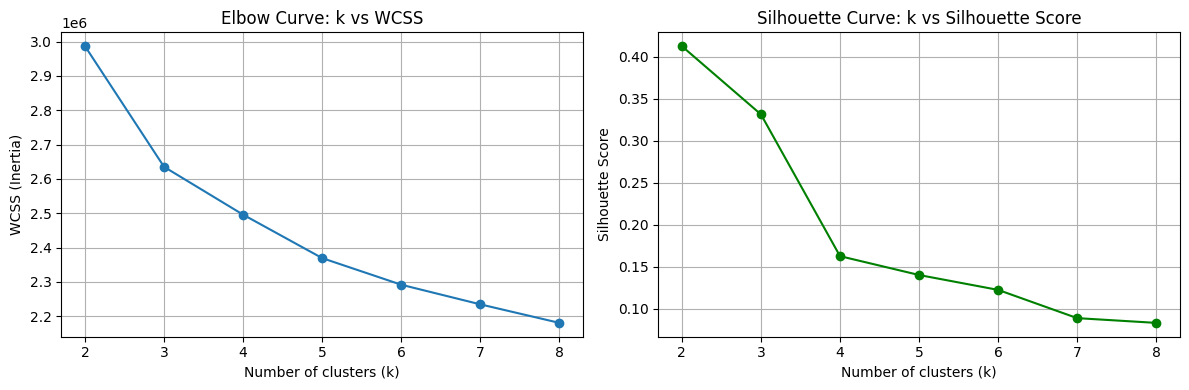

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(k_values, wcss, marker="o")
axes[0].set_title("Elbow Curve: k vs WCSS")
axes[0].set_xlabel("Number of clusters (k)")
axes[0].set_ylabel("WCSS (Inertia)")
axes[0].grid()

axes[1].plot(k_values, sil_scores, marker="o", color="green")
axes[1].set_title("Silhouette Curve: k vs Silhouette Score")
axes[1].set_xlabel("Number of clusters (k)")
axes[1].set_ylabel("Silhouette Score")
axes[1].grid()

plt.tight_layout()
plt.show()

In [10]:
# best k = the k with the highest silhouette score
best_k = k_values[int(np.argmax(sil_scores))]

print(f"Best k = {best_k}  (silhouette = {max(sil_scores):.3f})")
print(f"WCSS falls from {wcss[0]:.0f} (k=2) to {wcss[-1]:.0f} (k=8) - it never rises, so the elbow (bend) "
      f"has to be read from the curve together with the silhouette score.")
print(f"The dataset really has {true_k} activities, so k = {true_k} is also evaluated later for a fair comparison.")

Best k = 2  (silhouette = 0.413)
WCSS falls from 2986709 (k=2) to 2180422 (k=8) - it never rises, so the elbow (bend) has to be read from the curve together with the silhouette score.
The dataset really has 6 activities, so k = 6 is also evaluated later for a fair comparison.


**Justification of best k = 2:**
* The silhouette score is highest at k = 2 (0.413) and falls sharply to 0.331 at k = 3 and 0.162 at k = 4.
* The WCSS drops steeply from k = 2 to k = 3 (about 12 %) and much more slowly afterwards (about 5 % for k = 3 → 4), so the elbow is at k = 2–3; there is no sharp elbow for larger k.
* The data really has two well separated groups – *moving* (walking, upstairs, downstairs) and *not moving* (sitting, standing, laying). K-Means with k = 2 puts only 23 of 10299 windows on the wrong side (see the cross-table in Section 8).
* Because the dataset has 6 activities, k = 6 is also evaluated in the final comparison.

## 6. Model B – DBSCAN
DBSCAN has two parameters: **ε** (neighbourhood radius) and **minPts** (minimum points to form a dense region). Points are *core*, *border* or *noise* (label `-1`).

**Tuning:**
1. For every point, find the distance to its minPts-th nearest neighbour and sort them → **k-distance graph**. ε should sit where the curve starts rising steeply.
2. Try ε values taken from percentiles of these distances for a few minPts values and compare the results.
3. Pick the best silhouette among the *sensible* settings: at least 2 clusters, at most 30 % noise and **no giant cluster** (a setting that puts, say, 97 % of the points in one cluster can have a high silhouette but has separated nothing).

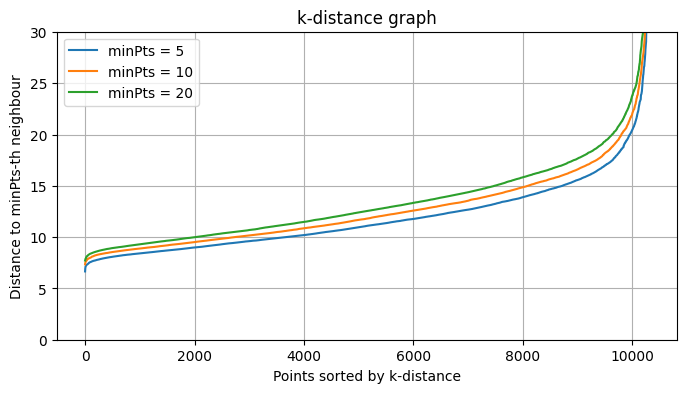

,eps,minPts,Clusters,Noise %,Largest cluster %,Silhouette (non-noise)
0,12.901245,5,19,22.633265,50.966113,0.305134
1,14.244893,5,18,13.671230,84.464511,0.140133
2,16.202977,5,6,6.427809,92.902224,0.055598
3,18.445804,5,4,3.175066,96.659870,0.342043
4,13.798020,10,11,20.031071,51.830275,0.302753
5,15.259162,10,3,11.069036,88.513448,0.320031
6,17.306690,10,2,5.388873,94.174192,0.333337
7,19.835544,10,1,2.631323,97.368677,NaN
8,14.638005,20,3,18.594038,80.939897,0.302997
9,16.213841,20,2,9.389261,90.270900,0.341953


In [11]:
rows = []
plt.figure(figsize=(8, 4))

for min_pts in [5, 10, 20]:
    # distance of every point to its min_pts-th nearest neighbour
    kdist = np.sort(NearestNeighbors(n_neighbors=min_pts).fit(X_cluster).kneighbors(X_cluster)[0][:, -1])
    plt.plot(kdist, label=f"minPts = {min_pts}")

    for eps in np.percentile(kdist, [70, 80, 90, 95]):
        lab = DBSCAN(eps=eps, min_samples=min_pts).fit_predict(X_cluster)
        mask = lab != -1                                   # -1 = noise
        n_clusters = len(set(lab[mask]))
        sil = silhouette_score(X_cluster[mask], lab[mask]) if n_clusters >= 2 else np.nan
        largest = np.bincount(lab[mask]).max() / len(lab) * 100 if mask.any() else 0
        rows.append({"eps": eps, "minPts": min_pts, "Clusters": n_clusters,
                     "Noise %": (~mask).mean() * 100, "Largest cluster %": largest,
                     "Silhouette (non-noise)": sil})

plt.ylim(0, np.percentile(kdist, 99))              # zoom in: a few extreme outliers would flatten the curve
plt.xlabel("Points sorted by k-distance")
plt.ylabel("Distance to minPts-th neighbour")
plt.title("k-distance graph")
plt.legend()
plt.grid()
plt.show()

dbscan_df = pd.DataFrame(rows)
dbscan_df

In [12]:
# choose the setting with the best silhouette among the "sensible" ones:
# >= 2 clusters, at most 30% noise, and no cluster holding more than 60% of all points
ok = dbscan_df[(dbscan_df["Clusters"] >= 2) & (dbscan_df["Noise %"] <= 30) & (dbscan_df["Largest cluster %"] <= 60)]
best_db = (ok if len(ok) > 0 else dbscan_df).sort_values("Silhouette (non-noise)", ascending=False).iloc[0]

db_labels = DBSCAN(eps=best_db["eps"], min_samples=int(best_db["minPts"])).fit_predict(X_cluster)

print(f"Chosen: eps = {best_db['eps']:.3f}, minPts = {int(best_db['minPts'])}")
print(f"Clusters found: {len(set(db_labels) - {-1})}, noise points: {(db_labels == -1).sum()} ({(db_labels == -1).mean() * 100:.1f}%)")

Chosen: eps = 12.901, minPts = 5
Clusters found: 19, noise points: 2331 (22.6%)


## 7. Model C – Hierarchical Agglomerative Clustering (HAC)
Bottom-up: every point starts as its own cluster and the two closest clusters are merged repeatedly. **Ward's linkage** merges the pair that increases the total within-cluster variance the least.

The **dendrogram** shows the merge order; the height is the merge distance (cut it horizontally to get k clusters). Only the last 30 merges are drawn because there are thousands of points.

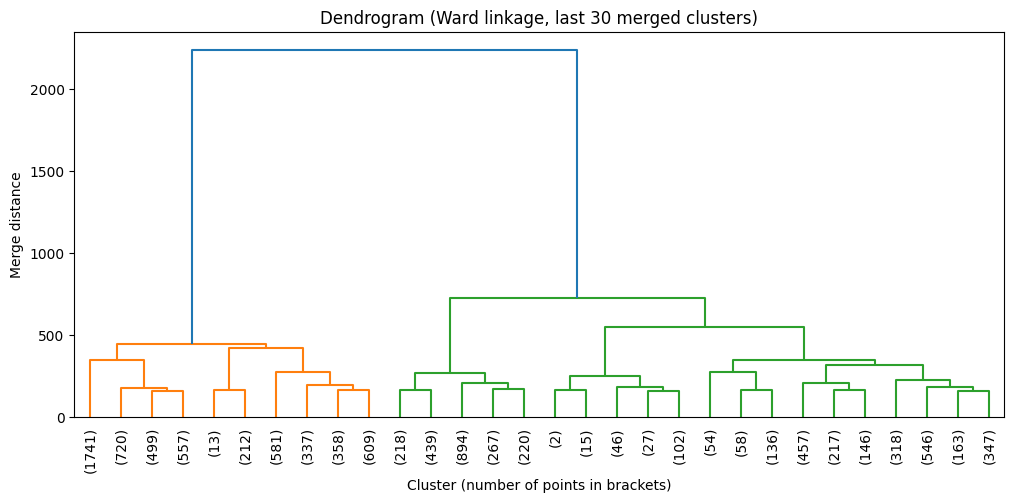

In [12]:
Z = linkage(X_cluster, method="ward")

plt.figure(figsize=(12, 5))
dendrogram(Z, truncate_mode="lastp", p=30, leaf_rotation=90)
plt.title("Dendrogram (Ward linkage, last 30 merged clusters)")
plt.xlabel("Cluster (number of points in brackets)")
plt.ylabel("Merge distance")
plt.show()

**Effect of the linkage criterion** – the same data clustered into 6 groups with four linkages:

In [13]:
rows = []
for link in ["single", "complete", "average", "ward"]:
    lab = AgglomerativeClustering(n_clusters=true_k, linkage=link).fit_predict(X_cluster)
    rows.append({"Linkage": link,
                 "Silhouette": silhouette_score(X_cluster, lab),
                 "ARI": adjusted_rand_score(y_true, lab),
                 "NMI": normalized_mutual_info_score(y_true, lab),
                 "Largest cluster %": np.bincount(lab).max() / len(lab) * 100})

linkage_df = pd.DataFrame(rows)
linkage_df

,Linkage,Silhouette,ARI,NMI,Largest cluster %
0,single,0.557067,0.000091,0.001296,99.941742
1,complete,0.320801,0.005875,0.045280,95.290805
2,average,0.441722,0.000242,0.005158,99.757258
3,ward,0.116694,0.500416,0.623965,34.148946


## 8. Final Clusters and Visualization
K-Means and HAC (Ward) are fitted with `best_k` and with `k = 6` (number of real activities); DBSCAN uses the parameters chosen above. The clusters are then drawn in 2-D (first two PCA components) next to the true activities.

In [14]:
all_labels = {}

for k in sorted({best_k, true_k}):
    all_labels[f"K-Means (k={k})"] = KMeans(n_clusters=k, n_init=10, random_state=42).fit_predict(X_cluster)

all_labels["DBSCAN"] = db_labels

for k in sorted({best_k, true_k}):
    all_labels[f"HAC-Ward (k={k})"] = AgglomerativeClustering(n_clusters=k, linkage="ward").fit_predict(X_cluster)

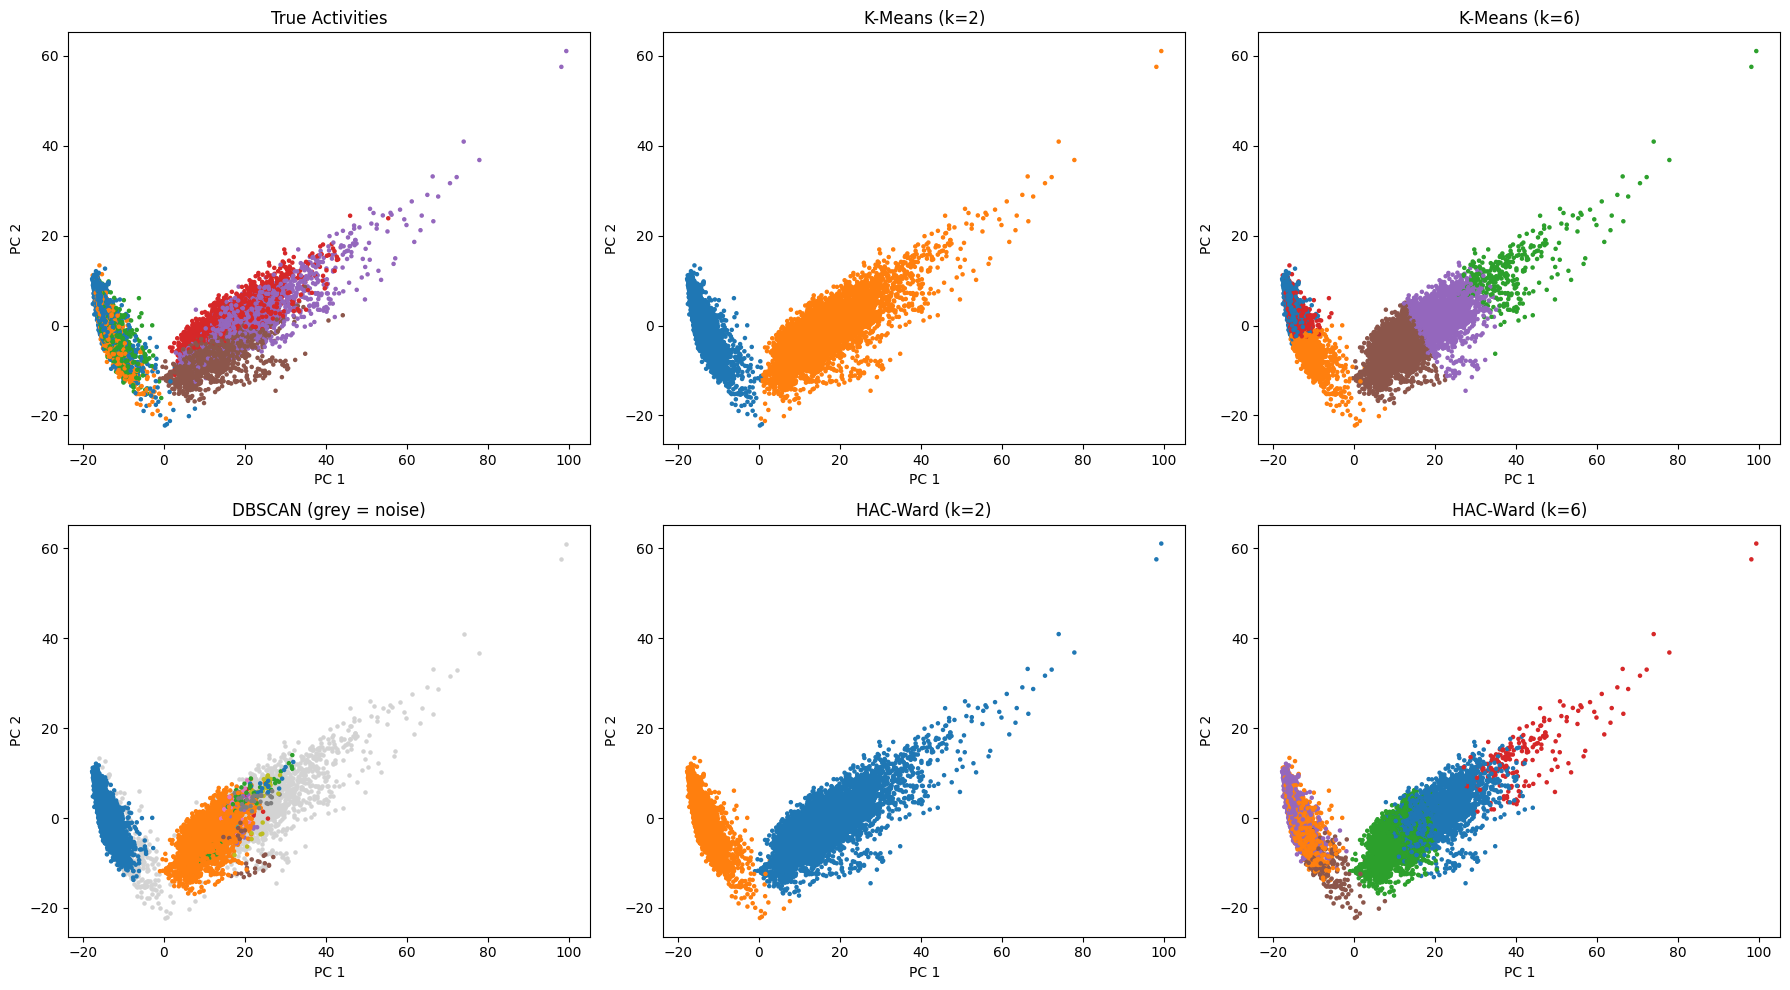

In [15]:
panels = {"True Activities": y_true, **all_labels}

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.ravel()

for ax, (title, lab) in zip(axes, panels.items()):
    noise = lab == -1                                  # DBSCAN noise points are drawn in grey
    ax.scatter(X_2d[noise, 0], X_2d[noise, 1], c="lightgrey", s=5)
    ax.scatter(X_2d[~noise, 0], X_2d[~noise, 1], c=lab[~noise] % 10, cmap="tab10", vmin=0, vmax=9, s=5)
    ax.set_title(title + (" (grey = noise)" if noise.any() else ""))
    ax.set_xlabel("PC 1")
    ax.set_ylabel("PC 2")

for ax in axes[len(panels):]:      # hide unused panels
    ax.axis("off")

plt.tight_layout()
plt.show()

**Clusters vs true activities** (confusion-style tables: rows = real activity, columns = cluster number)

In [16]:
for name, lab in all_labels.items():
    print(f"\n{name}")
    print(pd.crosstab(activity, lab, rownames=["Activity"], colnames=["Cluster"]))


K-Means (k=2)
Cluster                0     1
Activity                      
LAYING              1932    12
SITTING             1774     3
STANDING            1906     0
WALKING                0  1722
WALKING_DOWNSTAIRS     0  1406
WALKING_UPSTAIRS       8  1536

K-Means (k=6)
Cluster                0    1    2     3    4     5
Activity                                           
LAYING              1556  330    0    53    0     5
SITTING               91  451    0  1234    0     1
STANDING               0  566    0  1340    0     0
WALKING                0    0   84     0  741   897
WALKING_DOWNSTAIRS     0    0  214     0  883   309
WALKING_UPSTAIRS       0    2    9     0  297  1236

DBSCAN
Cluster              -1     0     1    2    3    4    5    6    7    8    9   \
Activity                                                                       
LAYING               185  1759     0    0    0    0    0    0    0    0    0   
SITTING              127  1650     0    0    0    0    0  

## 9. Evaluation Metrics
* **Internal** (no labels needed): Silhouette ↑, Davies–Bouldin ↓ (lower is better), Calinski–Harabasz ↑
* **External** (compared with the true activities): Adjusted Rand Index (ARI) ↑, Normalized Mutual Information (NMI) ↑

For DBSCAN the noise points are ignored in the internal metrics (they belong to no cluster); ARI / NMI treat noise as one extra group.

In [17]:
def evaluate(name, lab):
    mask = lab != -1                                   # ignore DBSCAN noise for internal metrics
    n_clusters = len(set(lab[mask]))
    if n_clusters >= 2:
        sil = silhouette_score(X_cluster[mask], lab[mask])
        dbi = davies_bouldin_score(X_cluster[mask], lab[mask])
        chi = calinski_harabasz_score(X_cluster[mask], lab[mask])
    else:
        sil = dbi = chi = np.nan
    return {"Algorithm": name, "Clusters": n_clusters,
            "Silhouette": sil, "Davies-Bouldin": dbi, "Calinski-Harabasz": chi,
            "ARI": adjusted_rand_score(y_true, lab),
            "NMI": normalized_mutual_info_score(y_true, lab)}

results_df = pd.DataFrame([evaluate(name, lab) for name, lab in all_labels.items()])
results_df

,Algorithm,Clusters,Silhouette,Davies-Bouldin,Calinski-Harabasz,ARI,NMI
0,K-Means (k=2),2,0.412516,1.019075,8635.778108,0.329611,0.545464
1,K-Means (k=6),6,0.122277,2.238548,2874.633751,0.419313,0.559276
2,DBSCAN,19,0.305134,1.447654,462.995396,0.310606,0.456096
3,HAC-Ward (k=2),2,0.412147,1.020010,8611.756783,0.332532,0.556789
4,HAC-Ward (k=6),6,0.116694,2.247593,2660.743712,0.500416,0.623965


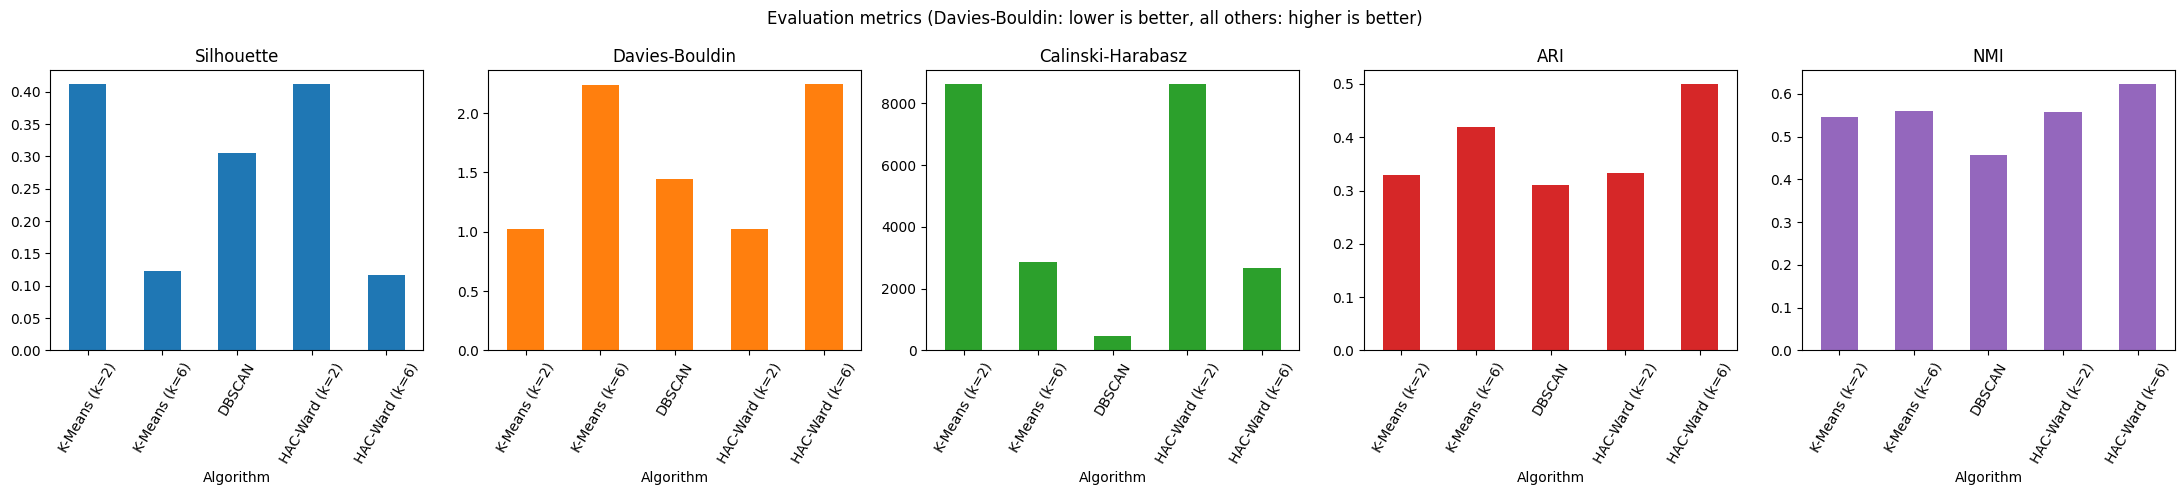

In [18]:
metrics = ["Silhouette", "Davies-Bouldin", "Calinski-Harabasz", "ARI", "NMI"]

results_df.set_index("Algorithm")[metrics].plot(
    kind="bar", subplots=True, layout=(1, 5), figsize=(22, 5), legend=False, rot=60)

plt.suptitle("Evaluation metrics (Davies-Bouldin: lower is better, all others: higher is better)")
plt.tight_layout()
plt.show()

## 10. Observations and Comparative Analysis
The cell below prints the facts that answer the five observation questions; the comments under it interpret them.

In [19]:
res = results_df.set_index("Algorithm")

# Q1 - most meaningful clusters (compared with the true activities)
print(f"Q1. Highest NMI: {res['NMI'].idxmax()} (NMI = {res['NMI'].max():.3f});  highest ARI: {res['ARI'].idxmax()} (ARI = {res['ARI'].max():.3f})")

# Q2 - sensitivity of K-Means to k
print(f"\nQ2. K-Means silhouette ranges from {min(sil_scores):.3f} to {max(sil_scores):.3f} for k = 2..8 (best k = {best_k}); "
      f"K-Means ARI with k={best_k}: {res.loc[f'K-Means (k={best_k})', 'ARI']:.3f}, with k={true_k}: {res.loc[f'K-Means (k={true_k})', 'ARI']:.3f}")

# Q3 - DBSCAN noise / small clusters
db_sizes = pd.Series(db_labels).value_counts()
print(f"\nQ3. DBSCAN: {len(set(db_labels) - {-1})} clusters, {(db_labels == -1).mean() * 100:.1f}% noise. Cluster sizes (label: points):")
print(db_sizes.to_dict())

# Q4 - effect of the linkage
print("\nQ4. Linkage comparison (k = 6):")
print(linkage_df.round(3).to_string(index=False))

# Q5 - which internal metric agrees with the ground truth / visual intuition
print("\nQ5. Best algorithm according to each metric:")
for m in metrics:
    best = res[m].idxmin() if m == "Davies-Bouldin" else res[m].idxmax()
    print(f"   {m:18s}: {best}")

Q1. Highest NMI: HAC-Ward (k=6) (NMI = 0.624);  highest ARI: HAC-Ward (k=6) (ARI = 0.500)

Q2. K-Means silhouette ranges from 0.083 to 0.413 for k = 2..8 (best k = 2); K-Means ARI with k=2: 0.330, with k=6: 0.419

Q3. DBSCAN: 19 clusters, 22.6% noise. Cluster sizes (label: points):
{0: 5249, 1: 2470, -1: 2331, 2: 45, 8: 24, 5: 21, 17: 20, 14: 19, 10: 18, 16: 18, 12: 16, 4: 13, 7: 9, 15: 9, 6: 8, 13: 7, 18: 7, 3: 5, 9: 5, 11: 5}

Q4. Linkage comparison (k = 6):
 Linkage  Silhouette   ARI   NMI  Largest cluster %
  single       0.557 0.000 0.001             99.942
complete       0.321 0.006 0.045             95.291
 average       0.442 0.000 0.005             99.757
    ward       0.117 0.500 0.624             34.149

Q5. Best algorithm according to each metric:
   Silhouette        : K-Means (k=2)
   Davies-Bouldin    : K-Means (k=2)
   Calinski-Harabasz : K-Means (k=2)
   ARI               : HAC-Ward (k=6)
   NMI               : HAC-Ward (k=6)


**Comments on the output above (results of this run)**

1. **Most meaningful clusters – HAC with Ward linkage.** With k = 6 it has the best ARI (0.500) and NMI (0.624), ahead of K-Means k = 6 (0.419 / 0.559), K-Means k = 2 (0.330 / 0.545) and DBSCAN (0.311 / 0.456). It isolates LAYING well (1809 of 1944 windows in one cluster). Ward with k = 2 splits *moving vs not moving* with **zero** mistakes. No algorithm separates SITTING from STANDING (they lie on top of each other in the feature space) and the three walking activities are also mixed, so ARI stays around 0.5.
2. **K-Means sensitivity to k – high.** The silhouette drops from 0.413 (k = 2) to 0.331 (k = 3), 0.162 (k = 4) and 0.083 (k = 8), while WCSS keeps decreasing smoothly (2.99 M → 2.18 M) with only a mild bend at k = 3. The internal criteria choose k = 2, but the agreement with the real activities is better for k = 6 (ARI 0.419 vs 0.330), so the "best" k depends on what we want from the clusters.
3. **DBSCAN – finds noise well, but not the activities.** The selected setting (ε = 12.9, minPts = 5) gives 2 big clusters – cluster 0 (5249 points) is *all three static activities together*, cluster 1 (2470 points) is mostly walking / upstairs – plus 17 tiny clusters of 5–45 points and 2331 noise points (22.6 %). The noise is concentrated in WALKING_DOWNSTAIRS (1123 of 1406 windows, ≈ 80 %), which are the most irregular, low-density windows. DBSCAN is also very sensitive to ε: from ε ≈ 16 upwards one cluster swallows more than 90 % of the points (see the parameter table).
4. **Effect of the linkage.** Single, complete and average linkage put 99.9 %, 95.3 % and 99.8 % of all windows into one cluster (ARI ≈ 0) because they first peel off the few extreme outliers. Ward minimises the within-cluster variance and gives balanced clusters (largest cluster 34 %, ARI 0.500), so it is the only linkage that works here.
5. **Internal metrics vs visual intuition.** Silhouette, Davies–Bouldin and Calinski–Harabasz all pick K-Means / HAC with k = 2, which matches the PCA scatter plot (two clearly separated groups) and the top split of the dendrogram; ARI / NMI prefer Ward with k = 6. The **silhouette score** matched the visual intuition best (its peak at k = 2 agrees with the elbow, the scatter plot and the dendrogram), but it must be read together with the cluster sizes: it gave single linkage the highest value (0.557) although 99.9 % of the points are in one cluster.